<a href="https://colab.research.google.com/github/chewanna7-code/NatureInsightStudy/blob/main/Heatmap_for_SS_and_Rank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Scenario Summary Heatmap Analysis

This notebook summarises the outputs generated during the NatureInsight® scenario analysis testing workflow and explores the relationship between Suitability Score (SS) thresholds and intervention rank.

The input file contains the total intervention area identified for each scenario combination. A pivot table is used to aggregate results and produce a heatmap showing how the spatial extent of recommended interventions changes across different ranking and suitability score settings.

### Purpose

The heatmap provides a rapid visual assessment of scenario sensitivity by highlighting:

- The influence of Suitability Score thresholds on intervention extent.
- The influence of intervention rank selection on intervention extent.
- Areas where changes in threshold or rank produce substantial differences in recommended intervention area.
- Potential points of diminishing returns where increasingly restrictive scenario settings result in limited additional change.

### Interpretation

- Higher values (darker colours) indicate a greater total intervention area identified by NatureInsight®.
- Lower values (lighter colours) indicate a smaller intervention area covered.
- Consistent patterns across rows or columns can indicate whether scenario outputs are more sensitive to rank selection or suitability score thresholds.
- The heatmap supports comparison of scenario behaviour and assists in identifying appropriate parameter settings for subsequent analysis.


Saving Untitled spreadsheet (2).xlsx to Untitled spreadsheet (2) (1).xlsx


/tmp/ipykernel_1416/4290601231.py:35: FutureWarning: The provided callable <function mean at 0x7e1fdef21940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  heatmap_data = df.pivot_table(


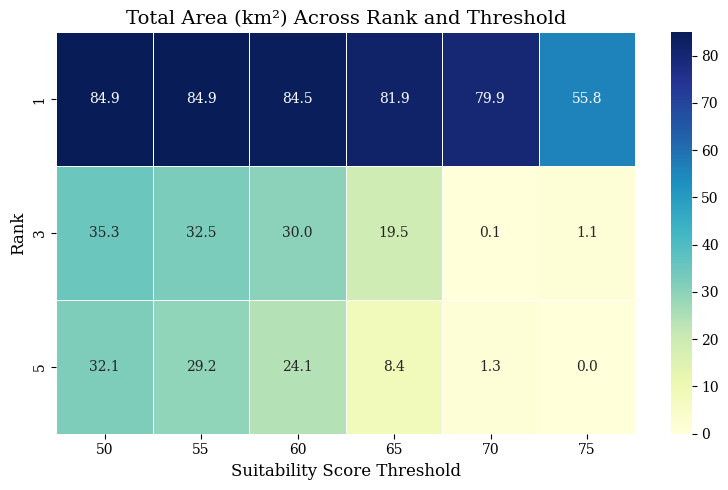

In [ ]:

# STEP 1: Upload file

from google.colab import files
uploaded = files.upload()


# STEP 2: Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for NaN

# STEP 3: Load Excel file

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)


# STEP 4: Clean Total Area column

df["Total Area (m²)"] = (
    df["Total Area (m²)"]
    .astype(str)
    .str.replace(",", "")
    .replace('#REF!', np.nan) # Replace '#REF!' with NaN
    .astype(float)
)

# STEP 5: Create pivot table

heatmap_data = df.pivot_table(
    index="Rank",
    columns="Threshold",
    values="Total Area (m²)",
    aggfunc=np.mean # Aggregate duplicate values by taking the mean
)

# Convert to km² for nicer display
heatmap_data = heatmap_data / 1_000_000

# STEP 6: Styling

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']


# STEP 7: Plot heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Total Area (km²) Across Rank and Threshold", fontsize=14)
plt.xlabel("Suitability Score Threshold", fontsize=12)
plt.ylabel("Rank", fontsize=12)

plt.tight_layout()

# Save high quality
plt.savefig("Heatmap_Area.png", dpi=300)

plt.show()